# Selfconsistent mean-field calculations with local/non-local interactions

`h.get_mean_field_hamiltonian(U=..., V1=..., V2=..., V3=..., filling=..., mf=...)` performs a
Hartree-Fock selfconsistency loop for an onsite Hubbard repulsion $U$ together with density-density
interactions to further shells ($V_1$, $V_2$, $V_3$, or an arbitrary distance-dependent $V_r$),

$$
H = \sum_{\langle ij\rangle} c^\dagger_i c_{j} + h.c.
+ U\sum_{i} n_{i\uparrow}n_{i\downarrow}
+ V_1\sum_{\langle ij\rangle,s,s'} n_{is}n_{js'} + ...
$$

Local and non-local terms can be switched on simultaneously in the same SCF loop: below, a
honeycomb lattice at quarter filling with both $U$ and $V_1$ develops a combined
charge-density-wave + magnetic state, seeded by a small sublattice-imbalance + Zeeman guess.

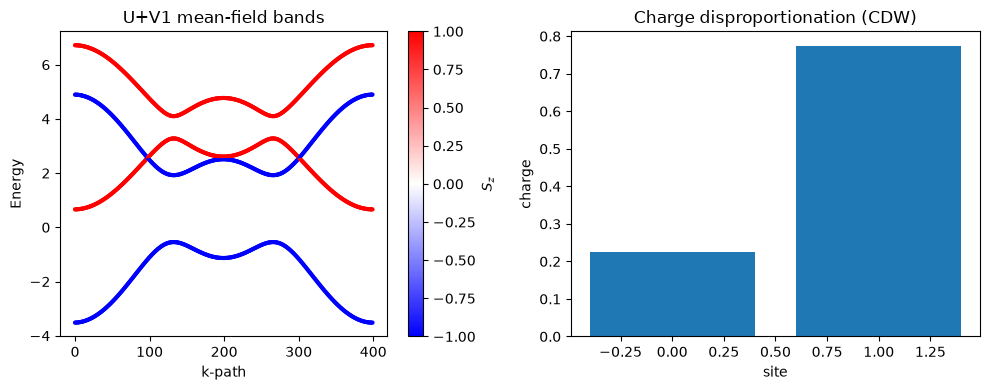

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian() # create hamiltonian of the system
# initial guess biasing both a CDW and a magnetic instability
h0 = h.copy()
h0.add_sublattice_imbalance(0.2)
h0.add_zeeman(2.0)

h = h.get_mean_field_hamiltonian(U=6.0,V1=1.5,mf=h0,mix=0.9,filling=0.25)
(k,e,c) = h.get_bands(operator="sz")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(k,e,c=c,cmap="bwr",s=4)
plt.colorbar(label="$S_z$")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("U+V1 mean-field bands")

plt.subplot(1,2,2)
plt.bar(range(len(h.geometry.r)),h.get_vev())
plt.xlabel("site") ; plt.ylabel("charge")
plt.title("Charge disproportionation (CDW)")
plt.tight_layout()
plt.show()